In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Set seed for reproducible synthetic generation
np.random.seed(42)
n_customers = 500
n_sales = 3000

# 1. Generate Customer Dataset
customer_ids = [f'CUST-{1000 + i}' for i in range(n_customers)]
cities = ['Mumbai', 'Bengaluru', 'Delhi', 'Chennai', 'Hyderabad', 'Pune']
segments = ['Consumer', 'Corporate', 'Small Business']

df_customers = pd.DataFrame({
    'Customer_ID': customer_ids,
    'Age': np.random.randint(18, 65, size=n_customers),
    'Gender': np.random.choice(['Male', 'Female'], size=n_customers, p=[0.52, 0.48]),
    'City': np.random.choice(cities, size=n_customers, p=[0.25, 0.25, 0.20, 0.12, 0.10, 0.08]),
    'Customer_Segment': np.random.choice(segments, size=n_customers, p=[0.60, 0.25, 0.15]),
    'Signup_Date': pd.date_range(start='2024-01-01', end='2025-12-31', periods=n_customers)
})

# 2. Generate Sales Dataset
categories = ['Electronics', 'Apparel', 'Home & Kitchen', 'Office Supplies']
dates = pd.date_range(start='2026-01-01', end='2026-08-20', periods=n_sales)

df_sales = pd.DataFrame({
    'Order_ID': [f'ORD-2026-{10000 + i}' for i in range(n_sales)],
    'Customer_ID': np.random.choice(customer_ids, size=n_sales),
    'Order_Date': np.random.choice(dates, size=n_sales),
    'Product_Category': np.random.choice(categories, size=n_sales, p=[0.35, 0.30, 0.20, 0.15]),
    'Unit_Price_INR': np.random.choice([499, 999, 1999, 4999, 14999, 29999], size=n_sales, p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]),
    'Quantity': np.random.choice([1, 2, 3, 5], size=n_sales, p=[0.70, 0.18, 0.08, 0.04]),
    'Discount_Pct': np.random.choice([0, 5, 10, 15, 20], size=n_sales)
})

# Feature Engineering
df_sales['Gross_Sales_INR'] = df_sales['Unit_Price_INR'] * df_sales['Quantity']
df_sales['Net_Sales_INR'] = (df_sales['Gross_Sales_INR'] * (1 - df_sales['Discount_Pct'] / 100)).round(2)

# Merge Datasets
df_merged = pd.merge(df_sales, df_customers, on='Customer_ID', how='inner')

print(f"Customer Records: {df_customers.shape[0]}")
print(f"Sales Transactions: {df_sales.shape[0]}")
print(f"Merged Dataset Shape: {df_merged.shape}\n")
df_merged.head()

Customer Records: 500
Sales Transactions: 3000
Merged Dataset Shape: (3000, 14)



,Order_ID,Customer_ID,Order_Date,Product_Category,Unit_Price_INR,Quantity,Discount_Pct,Gross_Sales_INR,Net_Sales_INR,Age,Gender,City,Customer_Segment,Signup_Date
0,ORD-2026-10000,CUST-1202,2026-06-09 18:01:48.036012004,Home & Kitchen,4999,1,10,4999,4499.10,20,Male,Bengaluru,Corporate,2024-10-22 12:15:52.304609216
1,ORD-2026-10001,CUST-1255,2026-05-10 00:25:55.718572858,Home & Kitchen,1999,3,5,5997,5697.15,42,Male,Hyderabad,Corporate,2025-01-08 01:06:22.364729456
2,ORD-2026-10002,CUST-1085,2026-01-23 22:53:15.465155051,Apparel,499,1,10,499,449.10,41,Female,Hyderabad,Corporate,2024-05-04 08:22:07.454909820
3,ORD-2026-10003,CUST-1149,2026-03-15 15:16:37.532510837,Electronics,4999,1,0,4999,4999.00,21,Male,Pune,Corporate,2024-08-05 23:25:22.244488976
4,ORD-2026-10004,CUST-1234,2026-08-08 05:09:42.194064688,Office Supplies,499,1,15,499,424.15,33,Female,Mumbai,Consumer,2024-12-08 07:47:29.699398796


/tmp/ipykernel_1327/2620235164.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_customers, x='Customer_Segment', y='Age', palette='Set2', ax=axes[1])


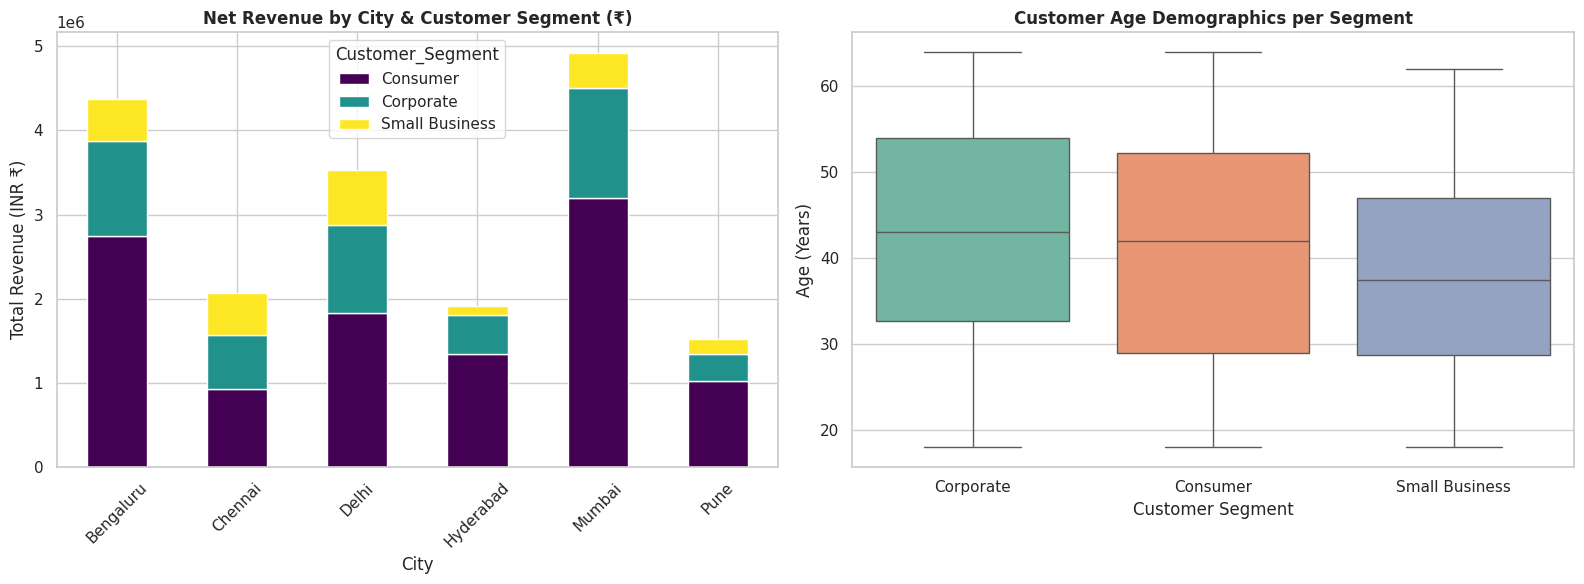

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Revenue Contribution by City & Segment
city_segment_rev = df_merged.groupby(['City', 'Customer_Segment'])['Net_Sales_INR'].sum().unstack()
city_segment_rev.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0])
axes[0].set_title('Net Revenue by City & Customer Segment (₹)', fontweight='bold')
axes[0].set_ylabel('Total Revenue (INR ₹)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Age Demographics per Segment
sns.boxplot(data=df_customers, x='Customer_Segment', y='Age', palette='Set2', ax=axes[1])
axes[1].set_title('Customer Age Demographics per Segment', fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Age (Years)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1327/130360514.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Net_Sales_INR', y='Product_Category', palette='Blues_r', ax=axes[1])


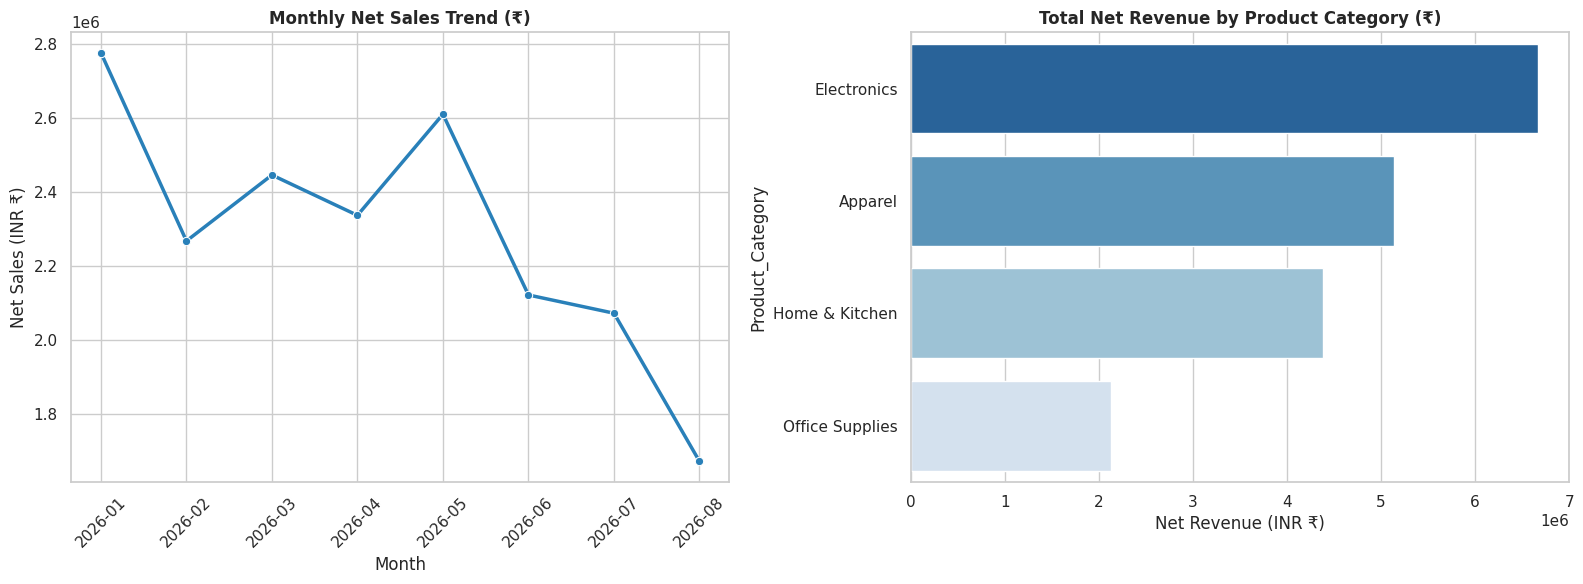

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Monthly Sales Revenue Trend
df_merged['Order_Month'] = df_merged['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df_merged.groupby('Order_Month')['Net_Sales_INR'].sum().reset_index()

sns.lineplot(data=monthly_sales, x='Order_Month', y='Net_Sales_INR', marker='o', color='#2980b9', linewidth=2.5, ax=axes[0])
axes[0].set_title('Monthly Net Sales Trend (₹)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Net Sales (INR ₹)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Revenue Share by Product Category
cat_revenue = df_merged.groupby('Product_Category')['Net_Sales_INR'].sum().reset_index().sort_values(by='Net_Sales_INR', ascending=False)
sns.barplot(data=cat_revenue, x='Net_Sales_INR', y='Product_Category', palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Net Revenue by Product Category (₹)', fontweight='bold')
axes[1].set_xlabel('Net Revenue (INR ₹)')

plt.tight_layout()
plt.show()

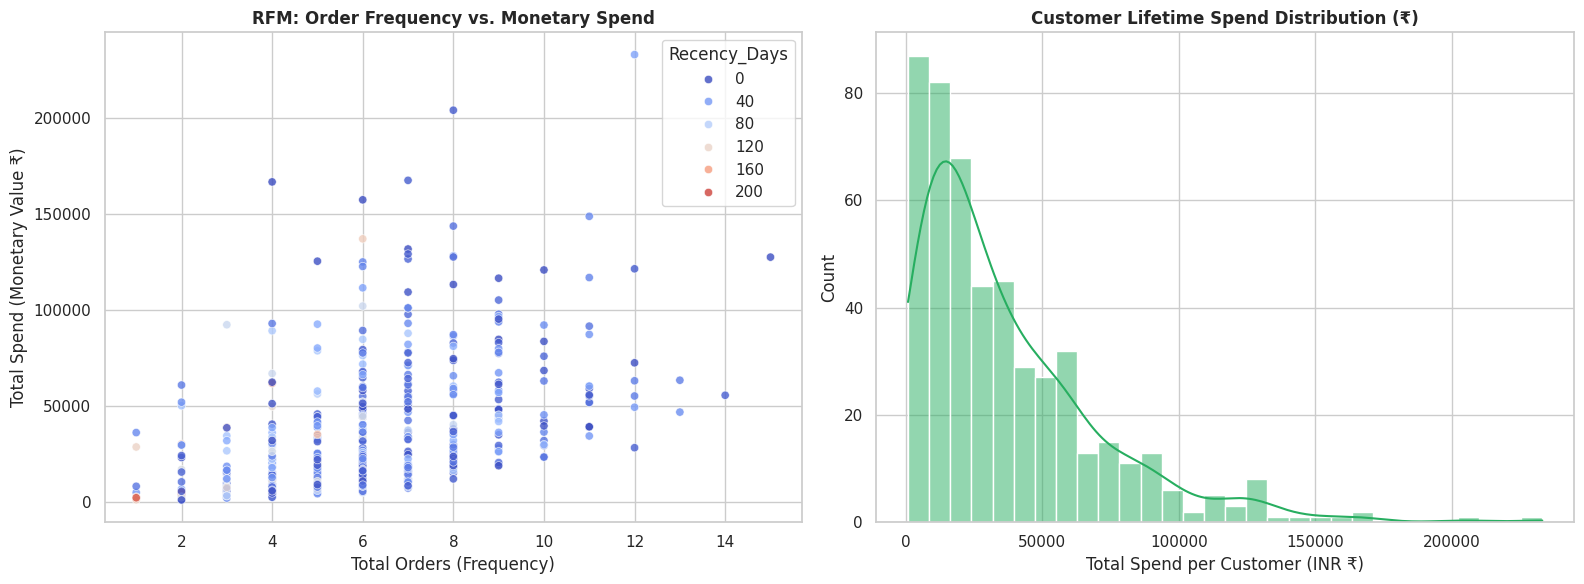

In [4]:
# Recency, Frequency, Monetary (RFM) Calculation
max_date = df_merged['Order_Date'].max()

rfm = df_merged.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (max_date - x.max()).days,
    'Order_ID': 'count',
    'Net_Sales_INR': 'sum'
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency_Days', 'Frequency', 'Monetary_Value']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Frequency vs. Monetary Value Scatter Plot
sns.scatterplot(data=rfm, x='Frequency', y='Monetary_Value', hue='Recency_Days', palette='coolwarm', alpha=0.8, ax=axes[0])
axes[0].set_title('RFM: Order Frequency vs. Monetary Spend', fontweight='bold')
axes[0].set_xlabel('Total Orders (Frequency)')
axes[0].set_ylabel('Total Spend (Monetary Value ₹)')

# 2. Customer Spend Distribution
sns.histplot(rfm['Monetary_Value'], kde=True, color='#27ae60', bins=30, ax=axes[1])
axes[1].set_title('Customer Lifetime Spend Distribution (₹)', fontweight='bold')
axes[1].set_xlabel('Total Spend per Customer (INR ₹)')

plt.tight_layout()
plt.show()

In [5]:
total_customers = df_customers['Customer_ID'].nunique()
active_customers = df_merged['Customer_ID'].nunique()
total_orders = len(df_sales)
total_net_revenue = df_merged['Net_Sales_INR'].sum()
avg_order_value = df_sales['Net_Sales_INR'].mean()
rev_per_customer = total_net_revenue / active_customers
repeat_customer_rate = (rfm['Frequency'] > 1).mean() * 100

kpi_dashboard = pd.DataFrame({
    'Executive Metric': [
        'Total Registered Customers',
        'Active Transacting Customers',
        'Customer Activation Rate',
        'Total Orders Placed',
        'Total Net Revenue',
        'Average Order Value (AOV)',
        'Average Revenue Per User (ARPU)',
        'Repeat Customer Purchase Rate'
    ],
    'Value': [
        f"{total_customers:,}",
        f"{active_customers:,}",
        f"{(active_customers/total_customers)*100:.1f}%",
        f"{total_orders:,}",
        f"₹{total_net_revenue:,.2f}",
        f"₹{avg_order_value:,.2f}",
        f"₹{rev_per_customer:,.2f}",
        f"{repeat_customer_rate:.1f}%"
    ]
})

print("=== EXECUTIVE KPI DASHBOARD ===")
kpi_dashboard

=== EXECUTIVE KPI DASHBOARD ===


,Executive Metric,Value
0,Total Registered Customers,500
1,Active Transacting Customers,498
2,Customer Activation Rate,99.6%
3,Total Orders Placed,"3,000"
4,Total Net Revenue,"₹18,312,329.45"
5,Average Order Value (AOV),"₹6,104.11"
6,Average Revenue Per User (ARPU),"₹36,771.75"
7,Repeat Customer Purchase Rate,98.6%


/tmp/ipykernel_1327/197748045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_discount, x='Product_Category', y='Discount_Pct', palette='Reds_r', ax=axes[0])


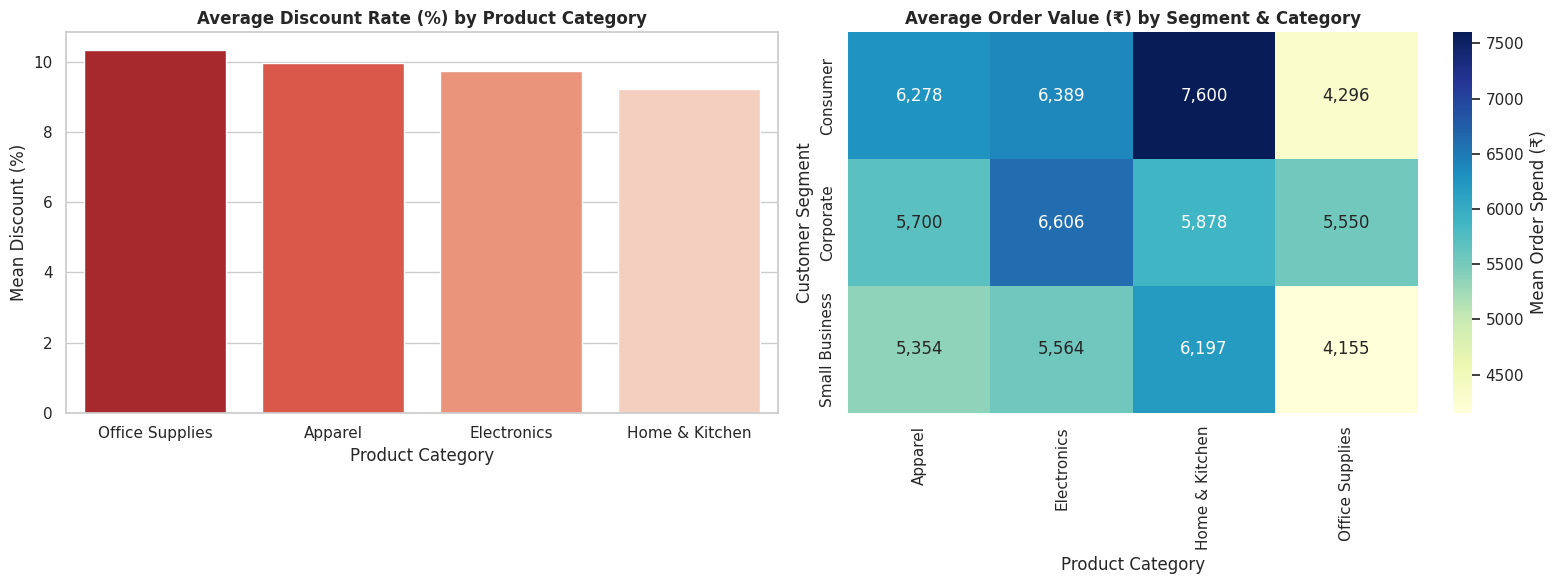

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average Discount Percentage Applied by Product Category
avg_discount = df_merged.groupby('Product_Category')['Discount_Pct'].mean().reset_index().sort_values(by='Discount_Pct', ascending=False)
sns.barplot(data=avg_discount, x='Product_Category', y='Discount_Pct', palette='Reds_r', ax=axes[0])
axes[0].set_title('Average Discount Rate (%) by Product Category', fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Mean Discount (%)')

# 2. Average Order Value (AOV) Heatmap: Segment vs Product Category
aov_matrix = df_merged.pivot_table(index='Customer_Segment', columns='Product_Category', values='Net_Sales_INR', aggfunc='mean')
sns.heatmap(aov_matrix, annot=True, fmt=',.0f', cmap='YlGnBu', cbar_kws={'label': 'Mean Order Spend (₹)'}, ax=axes[1])
axes[1].set_title('Average Order Value (₹) by Segment & Category', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Customer Segment')

plt.tight_layout()
plt.show()

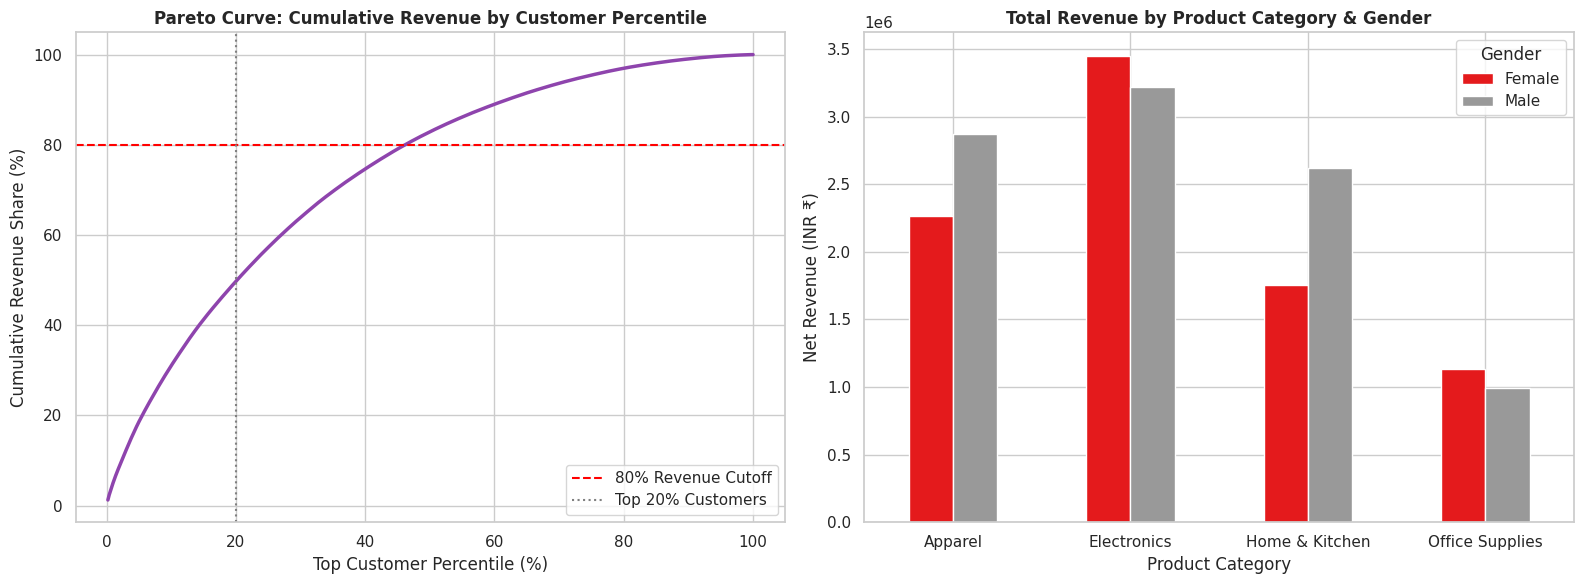

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Pareto Analysis (80/20 Rule on Customer Spend)
customer_spend = df_merged.groupby('Customer_ID')['Net_Sales_INR'].sum().sort_values(ascending=False).reset_index()
customer_spend['Cumulative_Revenue'] = customer_spend['Net_Sales_INR'].cumsum()
customer_spend['Cumulative_Pct'] = (customer_spend['Cumulative_Revenue'] / customer_spend['Net_Sales_INR'].sum()) * 100
customer_spend['Customer_Percentile'] = (np.arange(1, len(customer_spend) + 1) / len(customer_spend)) * 100

sns.lineplot(data=customer_spend, x='Customer_Percentile', y='Cumulative_Pct', color='#8e44ad', linewidth=2.5, ax=axes[0])
axes[0].axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% Revenue Cutoff')
axes[0].axvline(20, color='gray', linestyle=':', linewidth=1.5, label='Top 20% Customers')
axes[0].set_title('Pareto Curve: Cumulative Revenue by Customer Percentile', fontweight='bold')
axes[0].set_xlabel('Top Customer Percentile (%)')
axes[0].set_ylabel('Cumulative Revenue Share (%)')
axes[0].legend(loc='lower right')

# 2. Revenue Breakdown by Product Category & Gender
gender_cat = df_merged.groupby(['Product_Category', 'Gender'])['Net_Sales_INR'].sum().unstack()
gender_cat.plot(kind='bar', stacked=False, colormap='Set1', ax=axes[1])
axes[1].set_title('Total Revenue by Product Category & Gender', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Net Revenue (INR ₹)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1327/2308870290.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


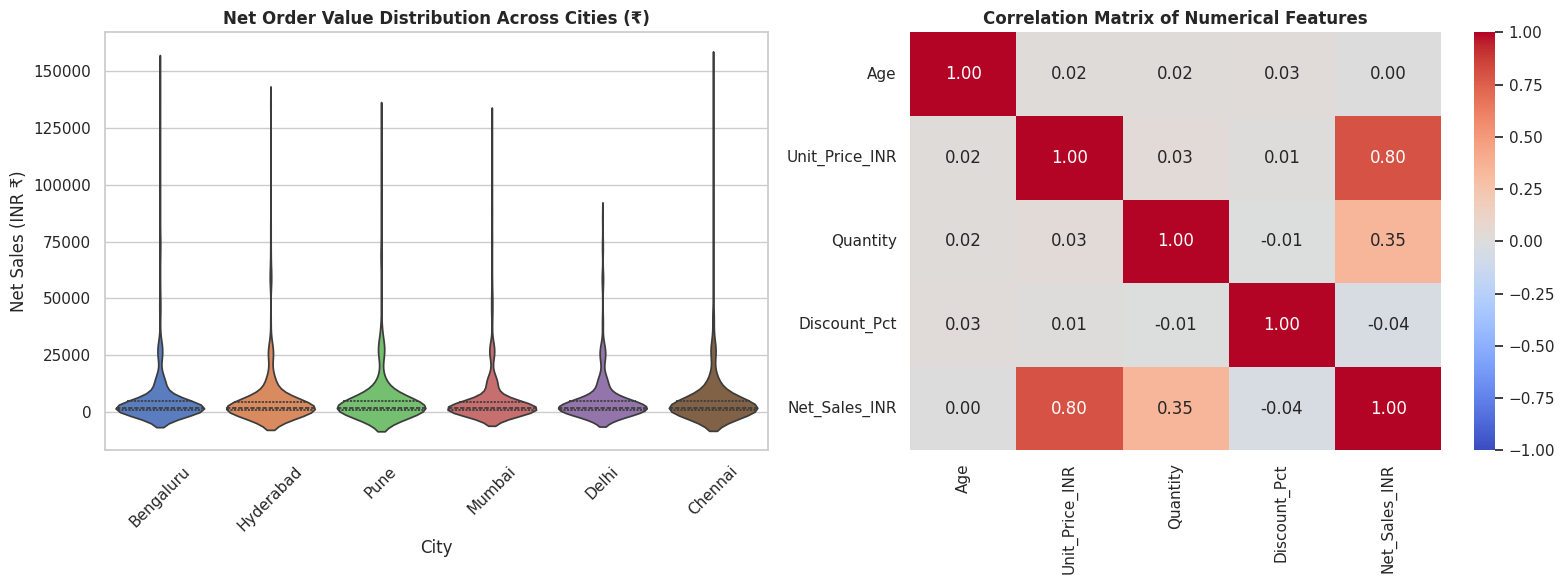

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Net Order Value Distribution Across Cities (Violin Plot)
sns.violinplot(
    data=df_merged, x='City', y='Net_Sales_INR',
    palette='muted', inner='quartile', ax=axes[0]
)
axes[0].set_title('Net Order Value Distribution Across Cities (₹)', fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Net Sales (INR ₹)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Correlation Matrix Heatmap of Numerical Attributes
numeric_cols = ['Age', 'Unit_Price_INR', 'Quantity', 'Discount_Pct', 'Net_Sales_INR']
corr_matrix = df_merged[numeric_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1]
)
axes[1].set_title('Correlation Matrix of Numerical Features', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1327/465565063.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_metrics = df_merged.groupby('Age_Group')['Net_Sales_INR'].sum().reset_index()
/tmp/ipykernel_1327/465565063.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_metrics, x='Age_Group', y='Net_Sales_INR', palette='crest', ax=axes[0])


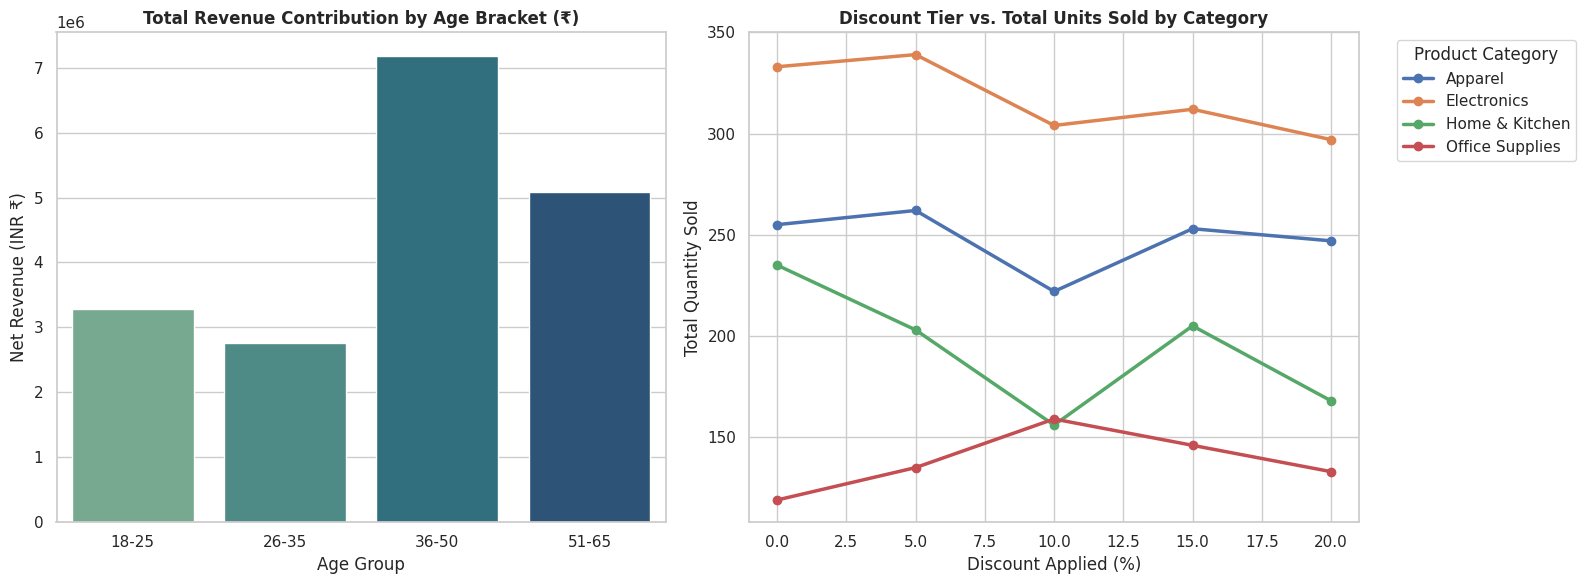

In [9]:
# Feature Engineering: Demographic Age Grouping
df_merged['Age_Group'] = pd.cut(
    df_merged['Age'],
    bins=[17, 25, 35, 50, 65],
    labels=['18-25', '26-35', '36-50', '51-65']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Total Net Sales by Demographic Age Bracket
age_metrics = df_merged.groupby('Age_Group')['Net_Sales_INR'].sum().reset_index()

sns.barplot(data=age_metrics, x='Age_Group', y='Net_Sales_INR', palette='crest', ax=axes[0])
axes[0].set_title('Total Revenue Contribution by Age Bracket (₹)', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Net Revenue (INR ₹)')

# 2. Impact of Discount Tier on Total Units Sold per Category
disc_qty = df_merged.groupby(['Discount_Pct', 'Product_Category'])['Quantity'].sum().unstack()

disc_qty.plot(kind='line', marker='o', linewidth=2.5, ax=axes[1])
axes[1].set_title('Discount Tier vs. Total Units Sold by Category', fontweight='bold')
axes[1].set_xlabel('Discount Applied (%)')
axes[1].set_ylabel('Total Quantity Sold')
axes[1].legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()